# Simon's Algorithm

In this module, you will:
- Understand how **Simon's algorithm** determines a hidden bitstring with an **exponential speedup** over any classical approach.
- Build the Simon's circuit step-by-step using the QpiAI Quantum SDK — both **manually** with `Circuit` and via the high-level `SimonAlgorithm` class.
- Analyze the **mathematical foundation**: Hadamard transforms, two-to-one oracles, and why measuring yields constraints $s \cdot y = 0 \pmod{2}$.
- Run experiments on a **simulator** and verify that the measurement outcomes are consistent with the hidden string.

## What is Simon's Algorithm?

We are given a black-box (oracle) function:

$$f : \{0,1\}^n \rightarrow \{0,1\}^n$$

with the **promise** that there exists a secret string $s \in \{0,1\}^n$ such that:

$$f(x) = f(y) \quad \text{if and only if} \quad y = x \oplus s$$

where $\oplus$ denotes bitwise XOR.

- If $s = 0^n$, the function is **one-to-one**.
- If $s \neq 0^n$, the function is **two-to-one**, with period $s$.

**The Challenge:** Given only oracle access to $f$, determine the hidden string $s$.

- **Classically**, any algorithm requires **$\Omega(2^{n/2})$ queries** in the worst case — an exponentially large number.
- **Quantumly**, Simon's algorithm finds $s$ using only **$O(n)$ oracle queries**, giving an **exponential quantum speedup**.

**Key Insight:** Simon's algorithm is one of the first to demonstrate an exponential quantum advantage and is a direct predecessor of **Shor's algorithm** for factoring integers.

## 1. Setup & Authentication

We reuse the same authentication pattern as previous modules: load `API_KEY` from `qcloud.env` and authenticate with `QpiAIQuantumAuth`.

In [ ]:
import os

from dotenv import load_dotenv
from qpiai_quantum import QpiAIQuantumAuth

load_dotenv("./qcloud.env") # This path should point to the env file containing your API key.

QpiAIQuantumAuth.login(os.getenv("API_KEY"))
user_info = QpiAIQuantumAuth.me()

print(f"✅ Authenticated successfully as: {user_info.get('name', 'User')} ({user_info.get('email', '')})")

## 2. SDK Primitives Used (This Module)

- `SimonAlgorithm` — high-level algorithm class that builds and runs Simon's circuit.
- `Circuit` — low-level circuit construction API (for manual circuit building).
- **Gates:** `h` (Hadamard), `cx` (CNOT).
- **Circuit utilities:** `show()`, `list_gates()`.
- **Execution:** `Circuit.run(shots=..., device_name="QpiAI-QSV-Local") (Note: `experiment_name` is optional and only required for cloud executions)`.
- **Results:** `result.counts`.

We will first build the circuit **manually** to understand each stage, then use the high-level `SimonAlgorithm` class for convenience.

## 3. Code: Building Simon's Circuit

Simon's circuit operates on **two registers**, each with $n$ qubits:
- An **input register** of $n$ qubits (qubits $0$ to $n-1$)
- An **output register** of $n$ qubits (qubits $n$ to $2n-1$)

The circuit has **four stages**:

1. **Superposition:** Apply $H^{\otimes n}$ to the input register to create a uniform superposition over all $n$-bit strings.
2. **Oracle:** Apply the oracle $U_f$ which maps $|x\rangle|y\rangle \to |x\rangle|y \oplus f(x)\rangle$.
3. **Decoding:** Apply $H^{\otimes n}$ to the input register again. The Hadamard transform converts the hidden period information into measurement constraints.
4. **Measurement:** Measure the $n$ input qubits. Each measurement yields a random $y$ satisfying $s \cdot y = 0 \pmod{2}$.

By repeating this process $O(n)$ times, we collect enough linearly independent equations to solve for $s$ via Gaussian elimination over $\mathrm{GF}(2)$.

### 3a. Manual Construction with `Circuit`

Let's build Simon's circuit for the hidden string $s = \texttt{"11"}$ (2-qubit input).

=== Manual Simon's Circuit for s = 11 ===


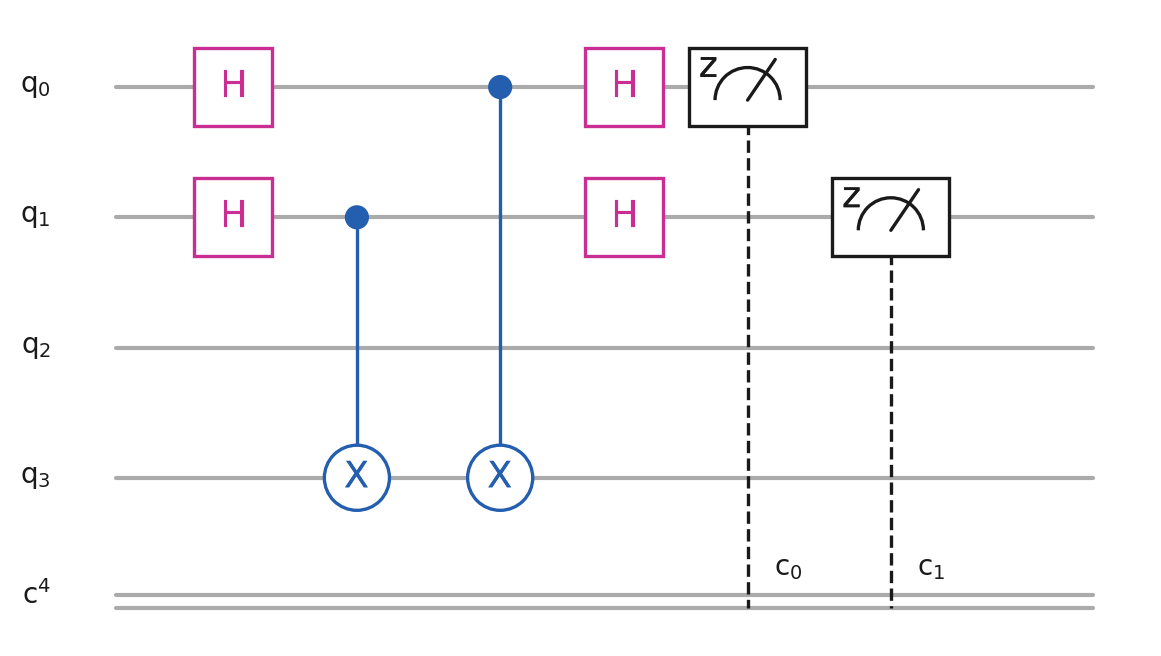

Gate stats: {'total_operations': 8, 'total_gates': 6, 'single_qubit_gates': 4, 'two_qubit_gates': 2, 'multi_qubit_gates': 0, 'clifford_gates': 6, 'non_clifford_gates': 0, 'parametric_gates': 0, 'measurements': 2, 'barriers': 0, 'gate_counts': {'H': 4, 'CX': 2, 'MEASURE': 2}}


In [2]:
from qpiai_quantum import Circuit

hidden_string = "11"
n = len(hidden_string)  # number of input qubits

# We need 2n qubits (n input + n output) and n classical bits
circuit = Circuit(2 * n, n, name="simon_manual_circuit")

# ── Stage 1: Put input qubits into superposition ──
# |0⟩^n → (1/√2^n) Σ_x |x⟩
for i in range(n):
    circuit.h(i)

# ── Stage 2: Oracle ──
# Reverse hidden string to match SDK big-endian measurement convention
reversed_s = hidden_string[::-1]

first_one = None
for j in range(n):
    if reversed_s[j] == '1':
        first_one = j
        break

# Step 1: Copy all input qubits to output, skipping first_one
for i in range(n):
    if i != first_one:
        circuit.cx(i, n + i)

# Step 2: XOR other '1' bits with input[first_one]
if first_one is not None:
    for k in range(n):
        if k != first_one and reversed_s[k] == '1':
            circuit.cx(first_one, n + k)

# ── Stage 3: Apply Hadamard to input register again ──
for i in range(n):
    circuit.h(i)

# ── Stage 4: Measure input qubits ──
for i in range(n):
    circuit.measure(i, i)

print(f"=== Manual Simon's Circuit for s = {hidden_string} ===")
circuit.show()
print("Gate stats:", circuit.list_gates())

### 3b. High-Level Construction with `SimonAlgorithm`

The SDK provides a convenient `SimonAlgorithm` class that wraps all four stages above.

Description: Simon's Algorithm - find hidden bitstring with exponential speedup

=== Simon's Circuit (high-level) ===


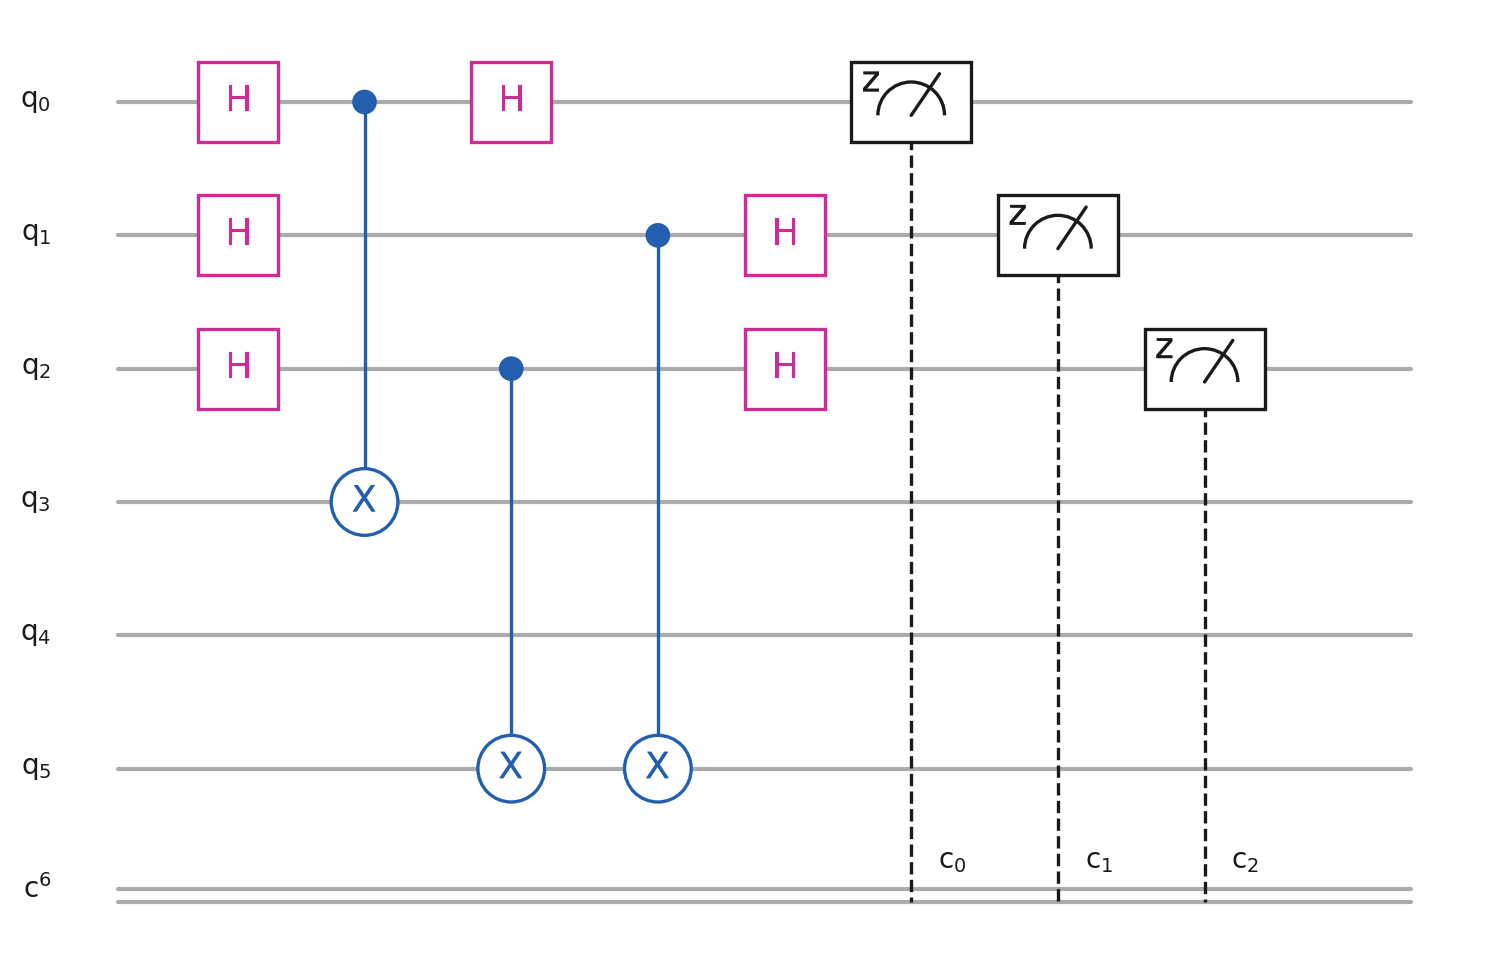

Gate stats: {'total_operations': 12, 'total_gates': 9, 'single_qubit_gates': 6, 'two_qubit_gates': 3, 'multi_qubit_gates': 0, 'clifford_gates': 9, 'non_clifford_gates': 0, 'parametric_gates': 0, 'measurements': 3, 'barriers': 0, 'gate_counts': {'H': 6, 'CX': 3, 'MEASURE': 3}}


In [3]:
from qpiai_quantum.algorithms.simon import SimonAlgorithm

# Create Simon's instance for a 3-qubit hidden string
simon = SimonAlgorithm(num_qubits=3, hidden_string="110")
print("Description:", simon.description)

# Build the circuit
simon_circuit = simon.build_circuit()
print("\n=== Simon's Circuit (high-level) ===")
simon_circuit.show()
print("Gate stats:", simon_circuit.list_gates())

## 4. Math: Why Simon's Algorithm Works

### The Full State Evolution

**Initial state:**
$$|\psi_0\rangle = |0\rangle^{\otimes n} |0\rangle^{\otimes n}$$

**After Stage 1 (Hadamard on input register):**
$$|\psi_1\rangle = \frac{1}{\sqrt{2^n}} \sum_{x \in \{0,1\}^n} |x\rangle |0\rangle^{\otimes n}$$

**After Stage 2 (Oracle query):**

The oracle $U_f$ acts as $U_f |x\rangle |y\rangle = |x\rangle |y \oplus f(x)\rangle$. Applying it:
$$|\psi_2\rangle = \frac{1}{\sqrt{2^n}} \sum_{x \in \{0,1\}^n} |x\rangle |f(x)\rangle$$

Because the function is two-to-one (when $s \neq 0^n$), the state can be grouped into pairs:
$$|\psi_2\rangle = \frac{1}{\sqrt{2^{n-1}}} \sum_{x \in \{0,1\}^n / \sim} \frac{1}{\sqrt{2}}\left( |x\rangle + |x \oplus s\rangle \right) |f(x)\rangle$$

**After measuring the second register:**

We obtain some value $f(x_0)$. The first register collapses to:
$$\frac{1}{\sqrt{2}} \left( |x_0\rangle + |x_0 \oplus s\rangle \right)$$

**After Stage 3 (Hadamard on input register again):**

Applying $H^{\otimes n}$ to this superposition:
$$H^{\otimes n} \frac{1}{\sqrt{2}} \left( |x_0\rangle + |x_0 \oplus s\rangle \right) = \frac{1}{\sqrt{2^{n+1}}} \sum_{y \in \{0,1\}^n} (-1)^{x_0 \cdot y} \left( 1 + (-1)^{s \cdot y} \right) |y\rangle$$

The amplitude is **non-zero only if:**
$$s \cdot y = 0 \pmod{2}$$

**After Stage 4 (Measurement):**

When we measure the input register, we obtain a random bitstring $y$ such that:
$$s \cdot y = s_1 y_1 \oplus s_2 y_2 \oplus \cdots \oplus s_n y_n = 0 \pmod{2}$$

Each measurement gives **one linear equation** over $\mathbb{F}_2$.

### Solving for the Hidden String

By repeating the algorithm $O(n)$ times, we collect enough equations to solve the system:
$$s \cdot y_1 = 0, \quad s \cdot y_2 = 0, \quad \ldots, \quad s \cdot y_k = 0$$

Using **Gaussian elimination in $\mathrm{GF}(2)$** yields the hidden string $s$.

### Classical vs Quantum Complexity

| Property | Classical | Quantum (Simon) |
|---|---|---|
| Oracle queries needed | $\Omega(2^{n/2})$ | $O(n)$ |
| Query strategy | Trial-and-error collisions | Superposition + Hadamard decoding |
| Speedup | — | Exponential |
| Post-processing | — | Gaussian elimination in $\mathrm{GF}(2)$ |

## 5. Experiment: Simulate and Verify

We will now run Simon's algorithm for **multiple hidden strings** and verify that the output bitstrings are consistent with $s \cdot y = 0 \pmod{2}$.

> **Simulator default:** `device_name="QpiAI-QSV-Local"`. To use a QPU, change `device_name` to `"QpiAI-Indus-1"` and configure an experiment with the same name in the QpiAI web UI.

> **Note:** The `experiment_name` parameter is omitted here because it is only required for cloud executions (e.g., on QCloud simulators or Indus QPU). For local simulation (`QpiAI-QSV-Local`), it is not needed.


In [4]:
def check_orthogonality(hidden_string, measured_bitstrings):
    """Check that all measured bitstrings satisfy s · y = 0 (mod 2)."""
    n = len(hidden_string)
    s_bits = [int(b) for b in hidden_string]
    all_valid = True
    for y_str in measured_bitstrings:
        y_bits = [int(b) for b in y_str]
        dot_product = sum(s_bits[i] * y_bits[i] for i in range(n)) % 2
        if dot_product != 0:
            all_valid = False
            print(f"  ❌ s·{y_str} = {dot_product} (should be 0)")
    return all_valid


# Test with several hidden strings
test_strings = ["11", "110", "10", "101"]
shots = 1024

results = {}
for s in test_strings:
    n = len(s)
    simon_inst = SimonAlgorithm(num_qubits=n, hidden_string=s)
    simon_inst.build_circuit()

    print(f"\n=== Hidden string: {s} (n={n}) ===")
    # Note: experiment_name is only required for cloud executions
    res = simon_inst.run(
        shots=shots,

        device_name="QpiAI-QSV-Local",
    )
    counts = res.counts or {}
    results[s] = counts

    print("Counts:", counts)

    # Verify: all measured bitstrings should satisfy s · y = 0 (mod 2)
    if counts:
        valid = check_orthogonality(s, counts.keys())
        status = "✅ All measurements valid" if valid else "❌ Some measurements invalid"
        print(status)


=== Hidden string: 11 (n=2) ===
Counts: {'00': 496, '11': 528}
✅ All measurements valid

=== Hidden string: 110 (n=3) ===
Counts: {'001': 253, '111': 249, '000': 260, '110': 262}
✅ All measurements valid

=== Hidden string: 10 (n=2) ===
Counts: {'00': 482, '01': 542}
✅ All measurements valid

=== Hidden string: 101 (n=3) ===
Counts: {'010': 267, '111': 254, '000': 255, '101': 248}
✅ All measurements valid



Plotting histogram for hidden string s = 110


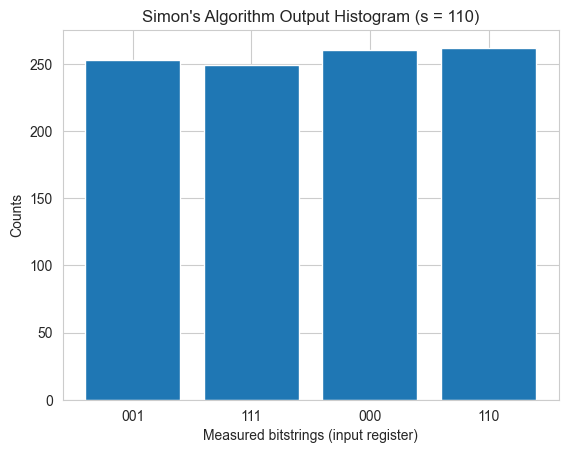

In [5]:
import matplotlib.pyplot as plt

# Visualize the histogram for one example
example_s = "110"
print(f"\nPlotting histogram for hidden string s = {example_s}")

counts = results.get(example_s, {})
bitstrings = list(counts.keys())
frequencies = list(counts.values())

plt.figure()
plt.bar(bitstrings, frequencies)
plt.xlabel("Measured bitstrings (input register)")
plt.ylabel("Counts")
plt.title(f"Simon's Algorithm Output Histogram (s = {example_s})")
plt.show()

### Results Interpretation

In the ideal (noiseless) case, you should observe:

- **Multiple peaks** in the histogram — unlike Bernstein-Vazirani, Simon's algorithm does NOT produce a single deterministic outcome.
- **All measured bitstrings** $y$ satisfy $s \cdot y = 0 \pmod{2}$.
- The measured outcomes form a **subspace** orthogonal to $s$ in $\mathbb{F}_2^n$.

**What the histogram shows:**
- **X-axis:** Measured $n$-bit outcomes from the input register.
- **Y-axis:** Count of each outcome.
- **Ideal case:** Multiple bars, all corresponding to bitstrings orthogonal to the hidden string $s$.
- **Noisy QPU:** The valid bitstrings still dominate, but occasional invalid outcomes may appear.

To actually **recover** the hidden string $s$, one must collect $n-1$ linearly independent measurements and solve the resulting system of equations using Gaussian elimination over $\mathrm{GF}(2)$.

### Using `find_hidden_string()` for Convenience

The `SimonAlgorithm` class also provides a `find_hidden_string()` method that runs the circuit multiple times, collects measurement outcomes, and solves the linear system to recover the hidden string.

In [6]:
simon_auto = SimonAlgorithm(num_qubits=3, hidden_string="110")
simon_auto.build_circuit()
recovered = simon_auto.find_hidden_string()
print(f"Hidden string: 110")
print(f"Recovered:     {recovered}")
print(f"Match: {'✅' if recovered == '110' else '❌'}")

Hidden string: 110
Recovered:     110
Match: ✅


## 6. Exercises

**Beginner:**

1. Run Simon's algorithm with the hidden string `"00"`. What do you expect to see? Since $s = 0^n$ means the function is one-to-one, all $2^n$ bitstrings should appear as valid measurements. Verify by running the circuit.
2. Try different hidden strings of varying lengths (e.g., 2, 3, 4 qubits). Do the measured bitstrings always satisfy $s \cdot y = 0$?

**Intermediate:**

3. Build Simon's circuit manually (using `Circuit`) for the hidden string `"101"` and display it with `show()`. Count the number of CX gates in the oracle stage — how does it relate to the number of `1`-bits in $s$?
4. Collect the measurement outcomes from multiple runs. Verify that they form a vector space (i.e., the XOR of any two valid outcomes is also a valid outcome).

**Advanced:**

5. Implement proper **Gaussian elimination in $\mathrm{GF}(2)$** to recover the hidden string from a set of measurement outcomes. Compare your result with `find_hidden_string()`.
6. Simon's algorithm is often cited as a predecessor of **Shor's algorithm**. Research and explain the connection: how does the idea of finding a hidden period generalize from $\mathbb{F}_2^n$ (Simon) to $\mathbb{Z}/N\mathbb{Z}$ (Shor)?

## 7. Key Takeaways

- **Simon's algorithm** finds a hidden bitstring $s$ using only **$O(n)$ oracle queries**, compared to $\Omega(2^{n/2})$ classically — an **exponential quantum speedup**.
- The circuit uses **two registers** of $n$ qubits each: one for input (superposition + Hadamard decoding) and one for the oracle output.
- Each run produces a random bitstring $y$ satisfying $s \cdot y = 0 \pmod{2}$. Repeating $O(n)$ times and solving via **Gaussian elimination in $\mathrm{GF}(2)$** recovers $s$.
- Unlike Bernstein-Vazirani (which needs **1 query**), Simon's algorithm needs **$O(n)$ queries** — but this is still exponentially better than classical.
- Simon's algorithm is a **direct predecessor of Shor's algorithm** — both exploit quantum parallelism to find hidden periodicities.
- The QpiAI SDK provides both a **low-level `Circuit` API** for manual construction and a **high-level `SimonAlgorithm` class** with methods like `build_circuit()`, `run()`, and `find_hidden_string()`.
- On the **statevector simulator**, the results are exact (only valid bitstrings appear). On real hardware, noise may introduce occasional invalid outcomes, but the valid bitstrings remain dominant.

---
**Thank you for learning with QpiAI!**

In [7]:
import qpiai_quantum
print(f"QpiAI Quantum SDK version: {qpiai_quantum.__version__}")

QpiAI Quantum SDK version: 0.1.32
